## Functional and Noisy Signal Population

In [1]:
# All Imports here
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Apply clean visual stylings
plt.style.use('seaborn-whitegrid' if 'seaborn-whitegrid' in plt.style.available else 'default')
# Runtime Configuration for visualizations
plt.rcParams['figure.dpi'] = 100
# reproducible stichastic generation through seed set
np.random.seed(seed=42)  # Set the seed for reproducibility

## 1. Trignometric Harmonic Signal + Additive Gaussian Noise

Harmonic signal generated successfully with gaussian noise.
Time Domain Array Length: 200
Pure signal range :[-3.00, 3.00] 
Noisy signal range :[-4.12, 3.88] 
Calculated Noise variance :0.3105


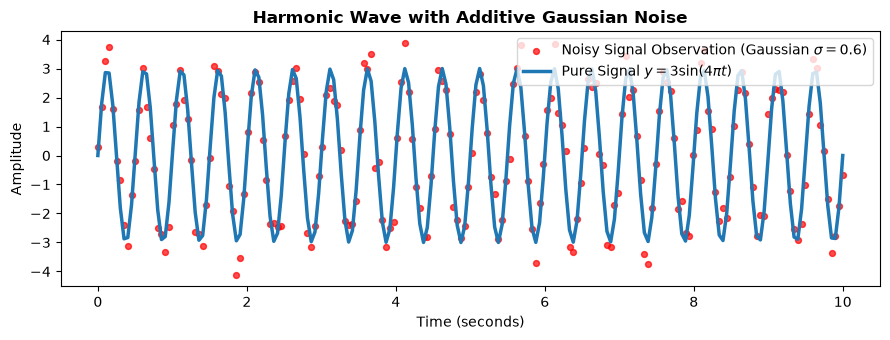

In [ ]:
t = np.linspace(
    start = 0,  # Start of the time interval
    stop = 10,  # End of the time interval
    num = 200  # Number of evenly spaced points
    )  

f = 2.0 # Frequency of the signal
A = 3.0  # Amplitude of the signal

# Generate the clean sinusoidal signal
y_pure = A * np.sin(2 * np.pi * f * t)

# Add Gaussian noise to the clean signal (mean = 0, standard deviation = 0.6)
gaussian_noise = np.random.normal(
    loc=0.0, # Mean of the Gaussian noise
    scale=0.6,  # Standard deviation of the Gaussian noise
    size=len(t)
    )

# Generate the noisy signal by adding the Gaussian noise to the clean signal
y_noisy = y_pure + gaussian_noise

print("Harmonic signal generated successfully with gaussian noise.")
print("Time Domain Array Length:", len(t))
print(f"Pure signal range :[{y_pure.min():.2f}, {y_pure.max():.2f}] ")
print(f"Noisy signal range :[{y_noisy.min():.2f}, {y_noisy.max():.2f}] ")
print(f"Calculated Noise variance :{np.var(gaussian_noise):.4f}")

plt.figure(figsize=(9, 3.5))

# noisy observation (scatter plot)
plt.scatter(
    x=t,                # X-coordinate (time values)
    y=y_noisy,          # Y-coordinate (noisy signal values)
    color='red',        # Color of the scatter points
    s=18 ,              # Size of the scatter points (marker size)
    alpha=0.7,          # Transparency of the scatter points
    zorder=2 ,           # Drawing order of the scatter points
    label='Noisy Signal Observation (Gaussian $\\sigma=0.6$)', # legend label for the scatter plot
    )

# Pure Underlying Signal (Line Plot)
plt.plot(
    t,                                                     # X-axis sequence (time values)
    y_pure,                                                # Y-axis sequence (clean signal values)
    color='#1f77b4',                                       # Standard dark blue line color
    linewidth=2.5,                                         # Thickness of the plot line
    zorder=3,                                              # Drawn on top of scatter points
    label='Pure Signal $y = 3\\sin(4\\pi t)$'               # Legend label entry
)

plt.title(
    label='Harmonic Wave with Additive Gaussian Noise',    # Figure title text
    fontsize=12,                                           # Title font size in points
    fontweight='bold'                                      
)

plt.xlabel(xlabel='Time (seconds)')                       # X-axis label text
plt.ylabel(ylabel='Amplitude')                            # Y-axis label text
plt.legend(loc='upper right')                             # Corner anchor position for legend box
plt.tight_layout()                                        # Automatically adjusts subplots to fit figure area
plt.show()

# Real world applications:
# 1. 🎵 Audio and microphones
# 2. ⚡ AC electrical signals
# 3. 📡 Communication systems

## 2.Exponential Decay + Uniform Measurment Error

=== 2. EXPONENTIAL DECAY + UNIFORM ERROR ===
Initial Pure Value at t=0: 10.00
Final Pure Value at t=5: 0.1832
Uniform Error Bounds: [-0.4856, 0.4759]



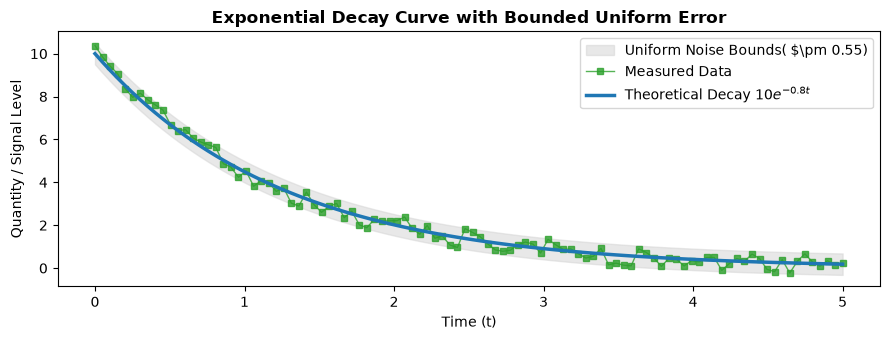

In [5]:
# Generate decay signal
t_decay = np.linspace(
    start=0.0,  # Start of time interval
    stop=5.0,   # End of time interval (5 seconds duration)
    num=100     # Total number of generated evaluation steps
)

N0 = 10.0  # Initial quantity at time t=0
decay_rate = 0.8 # decay constant lambda

# Generate the decay signal
y_decay_pure  = N0 * np.exp(-decay_rate * t_decay)

# generate bounded uniform measurement error in interval [-0.5, 0.5]
uniform_noise = np.random.uniform(
    low=-0.5,   # Lower bound of the uniform noise
    high=0.5,   # Upper bound of the uniform noise
    size=len(t_decay)  # Number of noise samples equal to the number of time points
)

# Generate the noisy decay signal by adding the uniform noise to the pure decay signal
y_decay_measured = y_decay_pure + uniform_noise


print("=== 2. EXPONENTIAL DECAY + UNIFORM ERROR ===")
print(f"Initial Pure Value at t=0: {y_decay_pure[0]:.2f}")
print(f"Final Pure Value at t=5: {y_decay_pure[-1]:.4f}")
print(f"Uniform Error Bounds: [{uniform_noise.min():.4f}, {uniform_noise.max():.4f}]\n")

# graphical representation of the decay signal
plt.figure(figsize=(9, 3.5))

# Bounded noise band visualization (shaded envelope)
plt.fill_between(
    x=t_decay,
    y1=y_decay_pure - 0.5,
    y2=y_decay_pure + 0.5,
    color='lightgray',  # Color of the shaded envelope
    alpha=0.5,          # Transparency of the shaded envelope
    label='Uniform Noise Bounds( $\\pm 0.55)'
)

# Plotting measured samples
plt.plot(
    t_decay,                                                # X-coordinates (time values)
    y_decay_measured,                                       # Y-coordinates (measured noisy signal values)
    's-',                                                   # Marker & line style format (square markers with solid line)
    color='#2ca02c',                                        # Forest green line color
    linewidth=1,                                            # Thickness of connecting line
    markersize=4,                                           # Vertex square marker side dimension
    alpha=0.8,                                              # Line opacity
    label='Measured Data'                                   # Legend label entry
)

plt.plot(
    t_decay,                                                # X-coordinates (time values)
    y_decay_pure,                                           # Y-coordinates (pure theoretical decay curve)
    color='#1f77b4',                                        # Dark blue color
    linewidth=2.5,                                          # Line thickness for ground truth curve
    label='Theoretical Decay $10 e^{-0.8t}$'                # Legend entry with LaTeX equation
)
plt.title(
    label='Exponential Decay Curve with Bounded Uniform Error',  # Plot title
    fontsize=12,                                                # Title text font size
    fontweight='bold'                                           # Bold title font weight
)
plt.xlabel(xlabel='Time (t)')                               # X-axis domain title
plt.ylabel(ylabel='Quantity / Signal Level')                # Y-axis range title
plt.legend(loc='upper right')                             # Position legend in upper right corner
plt.tight_layout()                                        # Optimize plot margin spacing
plt.show()

# Real-world examples
# ☢️ Radioactive material → number of radioactive atoms decreases
# ⚡ Capacitor discharge → voltage decreases
# 🌡️ Thermal cooling → temperature approaches room temperature
# 💊 Drug concentration → concentration can decrease over time

## Plynomial Functions + Spare Outliers (Salt and Peper / Impulse Noise)


=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===
Total Data Points: 120
Injected Outlier Count: 9
Outlier Indices: [  3  58 103  33  63  92  66 113   6]
Clean Data Mean: 0.6443 | Corrupted Data Mean: 0.6573



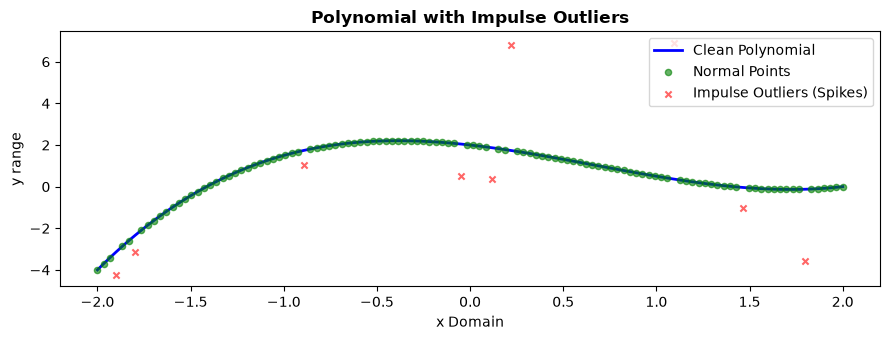

In [7]:
x_poly = np.linspace(
    start=-2.0,  # Lower domain boundary
    stop=2.0,    # Upper domain boundary
    num=120      # Total grid point resolution count
)

# Cubic Polynomial: p(x) = 0.5*x^3 - x^2 - x + 2
y_poly_clean = 0.5 * (x_poly**3) - (x_poly**2) - x_poly + 2
y_poly_corrupted = y_poly_clean.copy()

# select 8% of indices randomly to inject impulse spikes
num_outliers = int(0.08 * len(x_poly))  # 8% of the total number of points
outlier_indices = np.random.choice(
    a=len(x_poly),  # sampling population size index range
    size=num_outliers,  # Number of outlier indices to select
    replace=False       # Ensure unique selection of indices
)

# Inject random positive and negative spikes
spikes_magnitude = np.random.uniform(
    low=-4.0,   # Minimum spike magnitude
    high=8.0,   # Maximum spike magnitude
    size=num_outliers  # Number of spikes to generate
)
y_poly_corrupted[outlier_indices] += spikes_magnitude

print("=== 3. POLYNOMIAL + IMPULSE OUTLIERS ===")
print(f"Total Data Points: {len(x_poly)}")
print(f"Injected Outlier Count: {num_outliers}")
print(f"Outlier Indices: {outlier_indices}")
print(f"Clean Data Mean: {y_poly_clean.mean():.4f} | Corrupted Data Mean: {y_poly_corrupted.mean():.4f}\n")

plt.figure(figsize=(9, 3.5))
plt.plot(
    x_poly,                     # Domain coordinates
    y_poly_clean,               # Clean polynomial values
    label="Clean Polynomial",   # Legend label for the clean polynomial curve
    color="blue", 
    linewidth=2,
    zorder=2
    )

# Uncurrupted points (regular observations)
normal_mask = np.ones_like(x_poly, dtype=bool)
normal_mask[outlier_indices] = False

plt.scatter(
    x = x_poly[normal_mask],          # Domain coordinates for normal points
    y = y_poly_corrupted[normal_mask],# Corrupted polynomial values for normal points
    label="Normal Points",  # Legend label for normal observations
    color="green", 
    s=20,                         # Marker size
    zorder=3,
    alpha = 0.6
)

# Outlier points (impulse spikes highlighted in red)
plt.scatter(
    x = x_poly[outlier_indices],          # Domain coordinates for outlier points
    y = y_poly_corrupted[outlier_indices],# Corrupted polynomial values for outlier points
    label="Impulse Outliers (Spikes)",  # Legend label for outlier observations
    color="red", 
    s=20,                         # Marker size
    zorder=2,
    alpha = 0.6,
    marker="x"
)

plt.title(
    label="Polynomial with Impulse Outliers",
    fontsize=12,
    fontweight="bold"
)
plt.xlabel(xlabel="x Domain")
plt.ylabel(ylabel="y range")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Multi- Component Composite Signal  + Hetroscedastics Noise

=== 4. COMPOSITE SIGNAL + HETEROSCEDASTIC NOISE ===
Initial Noise Std Dev (t=0): 0.10
Final Noise Std Dev (t=10): 1.10
Overall Composite Signal Length: 300



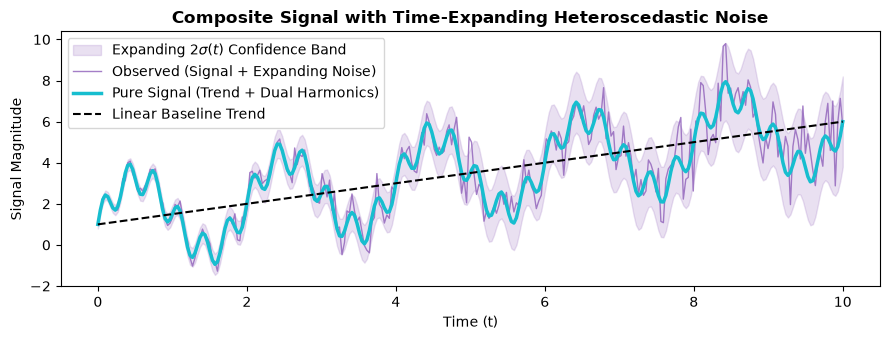

In [ ]:
t_comp = np.linspace(
    start=0.0,  # Start time in seconds
    stop=10.0,  # Stop time in seconds (10 second window)
    num=300     # Evaluation step count
)

trend = 0.5 * t_comp + 1.0 # Component 1: Linear upward trend (m=0.5, c=1.0)

harmonics = 2.0 * np.sin(2 * np.pi * 0.5 * t_comp) + 0.8 * np.sin(2 * np.pi * 3.0 * t_comp) # Component 2 & 3: Dual-frequency harmonics (0.5 Hz low freq + 3.0 Hz high freq)

S_pure = trend + harmonics # Combined signal: Trend + Harmonics

sigma_t = 0.1 + 0.1 * t_comp # Time-dependent standard deviation: sigma grows from 0.1 at t=0 to 1.1 at t=10

hetero_noise = np.random.normal(
    loc=0.0,           # Zero mean base noise distribution
    scale=1.0,         # Standard unit normal standard deviation
    size=len(t_comp)   # Sample size matching domain array length
) * sigma_t

y_composite = S_pure + hetero_noise # Final noisy signal: Pure signal + Heteroscedastic noise

print("=== 4. COMPOSITE SIGNAL + HETEROSCEDASTIC NOISE ===")
print(f"Initial Noise Std Dev (t=0): {sigma_t[0]:.2f}")
print(f"Final Noise Std Dev (t=10): {sigma_t[-1]:.2f}")
print(f"Overall Composite Signal Length: {len(y_composite)}\n")

# Graphical visualization
plt.figure(figsize=(9, 3.5))

plt.fill_between(
    x = t_comp,                      # Time axis coordinates
    y1 = S_pure - 2 * sigma_t,           # Lower 2-sigma lower envelope threshold
    y2 = S_pure + 2 * sigma_t,            # Upper 2-sigma upper envelope threshold
    color='#9467bd',                                             # Soft purple fill color
    alpha=0.2,                                                     # Envelope translucent shading factor
    label='Expanding $2\\sigma(t)$ Confidence Band'
)

# Observed composite series plot
plt.plot(
    t_comp,                                                        # Time grid
    y_composite,                                                   # Signal + heteroscedastic noise observations
    color='#9467bd',                                               # Muted purple line color
    linewidth=1.0,                                                 # Thin line for noisy signal details
    alpha=0.85,                                                    # Translucency level
    label='Observed (Signal + Expanding Noise)'                    # Legend text
)

plt.plot(
    t_comp,                                                        # Time grid
    S_pure,                                                        # Pure combined signal values
    color='#17becf',                                               # Cyan line color
    linewidth=2.5,                                                 # Line stroke thickness
    label='Pure Signal (Trend + Dual Harmonics)'                  # Legend text
)

plt.plot(
    t_comp,                                                        # Time grid
    trend,                                                         # Trend line component
    'k--',                                                         # Black dashed line format
    linewidth=1.5,                                                 # Dashed line thickness
    label='Linear Baseline Trend'                                  # Legend entry
)

plt.title(
    label='Composite Signal with Time-Expanding Heteroscedastic Noise', # Title
    fontsize=12,                                                        # Font size
    fontweight='bold'                                                   # Bold title font style
)

plt.xlabel(xlabel='Time (t)')                                       # X-axis label
plt.ylabel(ylabel='Signal Magnitude')                               # Y-axis label
plt.legend(loc='upper left')                                        # Top left legend positioning
plt.tight_layout()                                                  # Compact auto layout
plt.show()

# Real-world example: financial data: stock price.